# Analysis of MNase-seq replication timing

March 25, 2024

This notebook aims to examine the raw MNase-seq data and compare to the Brewer replication timing.



In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
from cc_src.chromatin_model import read_chromosome_mnase_reads

replicate = 1
chrom = 4

mnase_reads = read_chromosome_mnase_reads(replicate, chrom)


In [12]:
chrom_read_counts = mnase_reads.groupby(['sample', 'mid']).count()
chrom_read_counts = chrom_read_counts[['start']].rename(columns={'start': 'count'})

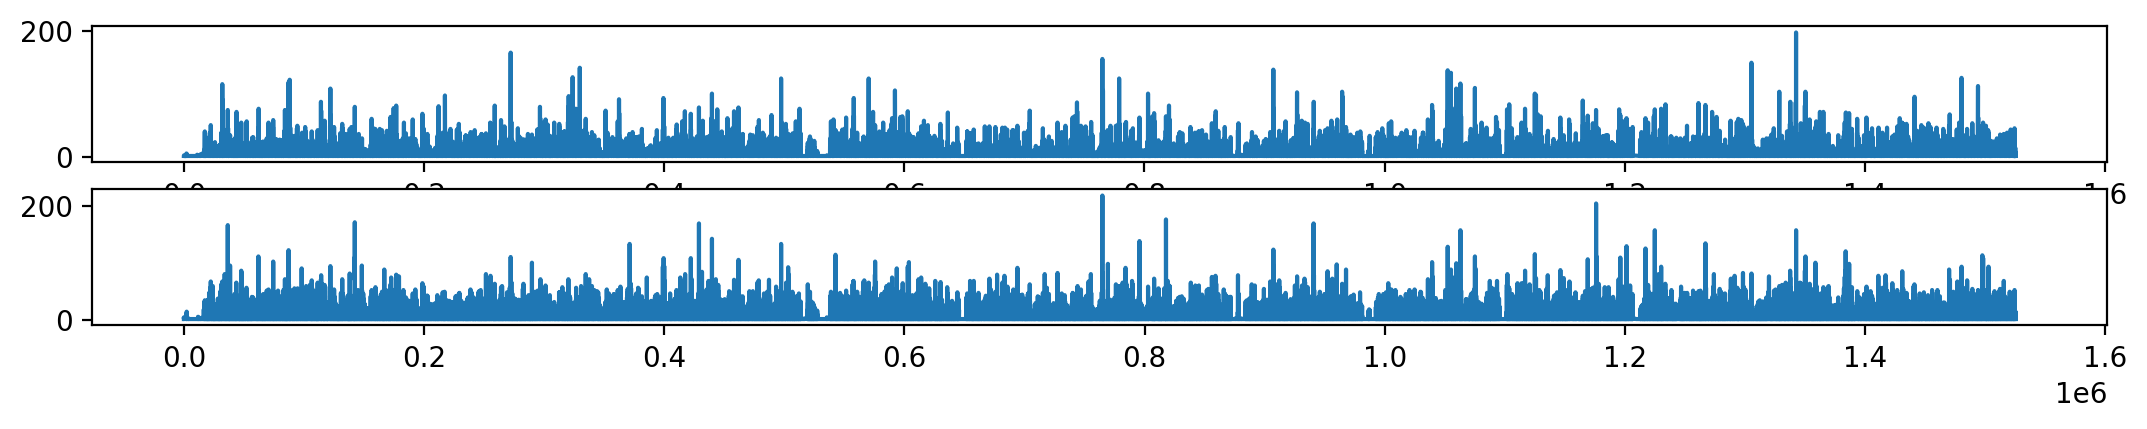

In [13]:
fig = plt.figure(figsize=(13, 3))
plt.subplot(3, 1, 1)
plt.plot(chrom_read_counts.loc[0])

plt.subplot(3, 1, 2)
plt.plot(chrom_read_counts.loc[140])

In [14]:
from cc_src.sgd import get_chromosome_length

chrom_len = get_chromosome_length(chrom)


(array([1158271,    9975,     945,     165,      54,      17,       6,
              7,       1,       2]),
 array([  1. ,  22.7,  44.4,  66.1,  87.8, 109.5, 131.2, 152.9, 174.6,
        196.3, 218. ]))

In [93]:
def sliding_window_approach(data, window_size, step):
    # Number of windows
    n_windows = (len(data) - window_size) // step + 1
    
    # Initialize an array to hold the result
    result = np.empty((n_windows, window_size))
    
    for i in range(n_windows):
        start = i * step
        result[i, :] = data[start:start + window_size]
    
    return result

In [125]:
counts = chrom_read_counts.loc[140]['count']
new_index = pd.RangeIndex(start=0, stop=chrom_len)
reindexed_series = counts.reindex(new_index)
counts = reindexed_series.fillna(0)

window_size = 10000
step = 5000

shape = ((counts.size - window_size) // step + 1, window_size)
strides = (data.strides[0] * step, data.strides[0])

# Generate the start indices for each window
num_windows = (counts.size - window_size) // step + 1
start_indices = np.arange(num_windows) * step


In [126]:
result = sliding_window_approach(counts, window_size, step)

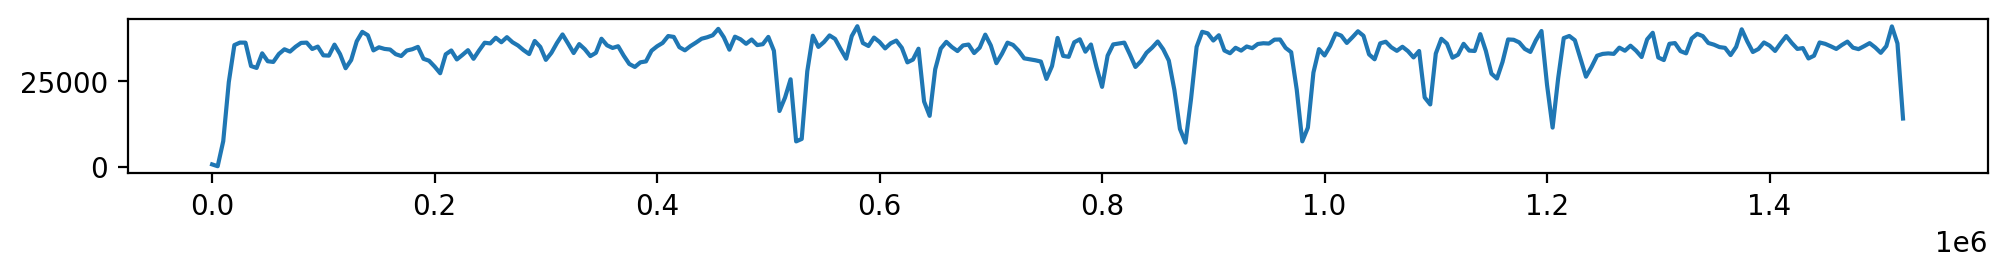

In [127]:
plt.figure(figsize=(12, 1))
plt.plot(start_indices, result.sum(axis=1))

In [130]:
result.shape

(305, 10000)